<a href="https://colab.research.google.com/github/jfleon-dev/university-ai-labs/blob/main/Keras_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificador binario

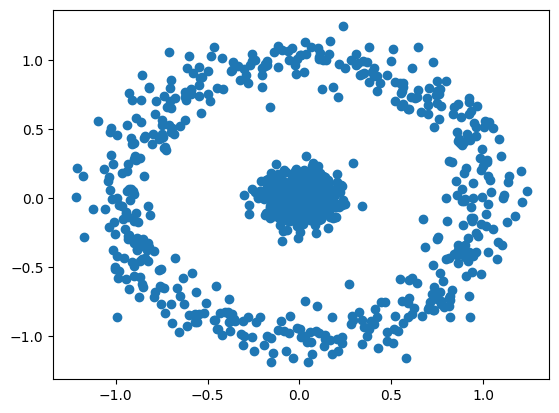

In [ ]:
#Datos de ejemplo

from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import numpy as np

X,y=make_circles(n_samples=1000,noise=0.1,factor=0.01,random_state=1)
plt.scatter(X[:,0],X[:,1])
plt.show()


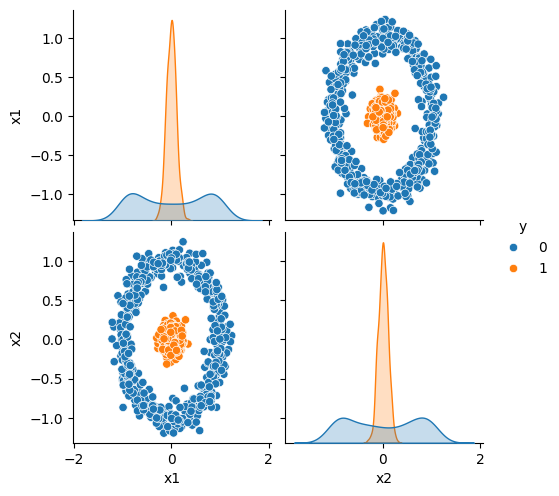

In [ ]:
import seaborn as sns
import pandas as pd

X_df=pd.DataFrame(X)
y_df=pd.DataFrame(y)
df = pd.concat([X_df, y_df], axis=1)
df.columns = ['x1', 'x2', 'y']
sns.pairplot(df,hue='y')
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model = Sequential()
model.add(Dense(40, input_shape=(2,)))
model.add(Dense(300, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='sgd',loss='binary_crossentropy')
model.fit(X_df, y_df, epochs=10)
preds = model.predict(X_df)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6933
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6798 
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6685 
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6532 
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6360 
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6202 
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5999
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5849
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5659 
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5478
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


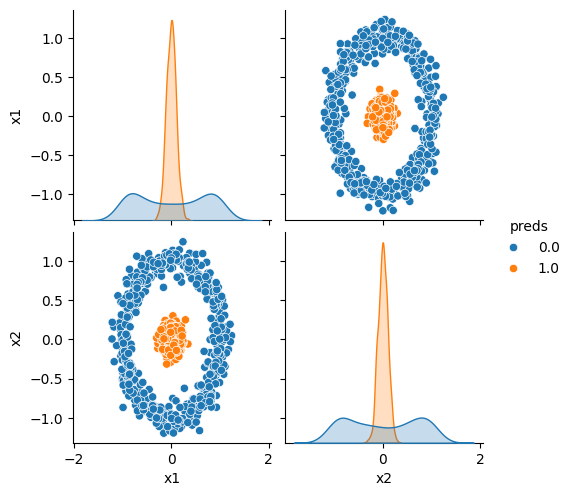

In [ ]:
predicciones = pd.DataFrame(np.round(preds))
tabla_preds = pd.concat([X_df, predicciones], axis=1)
tabla_preds.columns = ['x1', 'x2', 'preds']

sns.pairplot(tabla_preds,hue='preds')

## Ejercicio. Explorando billetes de dólar

Practicarás la construcción de modelos de clasificación en Keras con el conjunto de datos "Autenticación de Billetes".

Tu objetivo es distinguir entre billetes de dólar reales y falsos. Para ello, el conjunto de datos incluye cuatro características: varianza, asimetría, curtosis y entropía. Estas características se calculan aplicando operaciones matemáticas a las imágenes de los billetes de dólar. Las etiquetas se encuentran en la columna de clase del marco de datos.

Instrucciones
1. Visualiza los puntos de datos para ver si es posible crear un modelo clasificador
2. Crea una red neuronal y entrenala para clasificar billetes reales o falsos.
3. Prueba tu red neuronal haciendo predicciones sobre los datos originales y visualizando el resultado.
4. Determina la cantidad de billetes que se identificaron correctamente.

In [ ]:
import pandas as pd

tabla_csv = pd.read_csv('banknotes.csv')
tabla_csv.head()

,variace,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
z_df = tabla_csv.drop(columns=['class'], axis = 1)
w_df = tabla_csv['class']

1. Visualiza los puntos de datos para ver si es posible crear un modelo clasificador


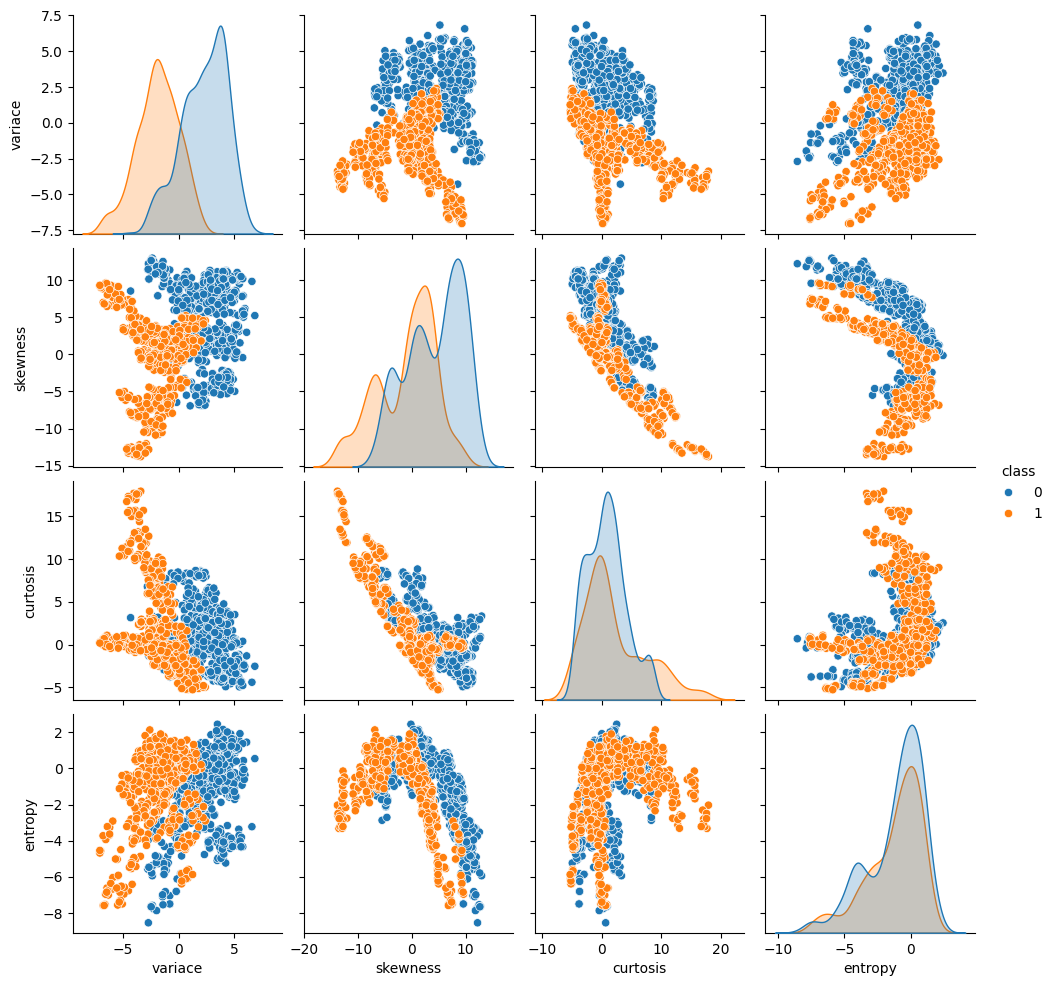

In [ ]:
import seaborn as sns

df = pd.concat([z_df, w_df], axis=1)
sns.pairplot(df,hue='class')
plt.show()

2. Crea una red neuronal y entrenala para clasificar billetes reales o falsos.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model = Sequential()
model.add(Dense(40, input_shape=(4,)))
model.add(Dense(300, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='sgd',loss='binary_crossentropy')
model.fit(z_df, w_df, epochs=10)
preds = model.predict(z_df)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4410
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2165
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1593
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1093
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0932
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0805
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0650
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0580
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0508
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0434
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


3. Prueba tu red neuronal haciendo predicciones sobre los datos originales y visualizando el resultado.


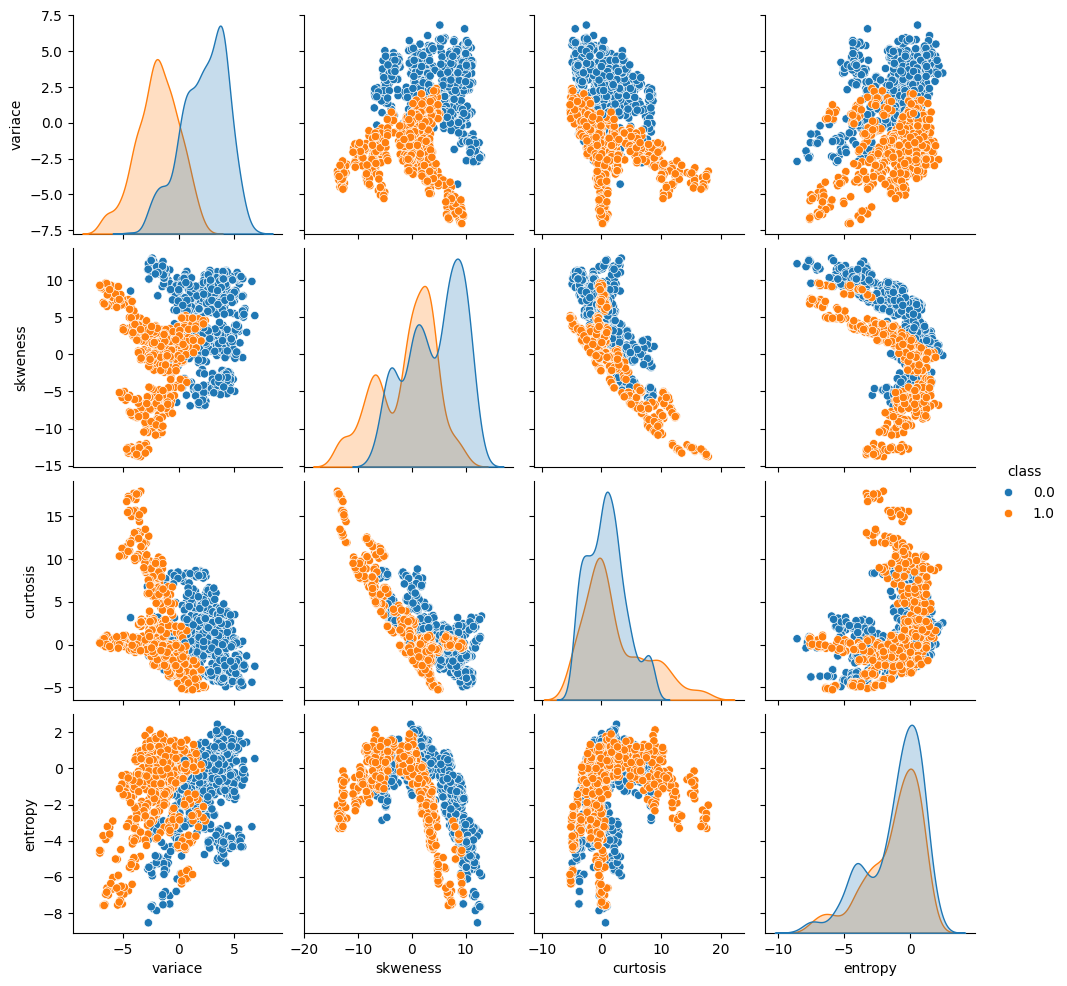

In [ ]:
predicciones = pd.DataFrame(np.round(preds))
tabla_preds = pd.concat([z_df, predicciones], axis=1)
tabla_preds.columns = ['variace', 'skweness', 'curtosis', 'entropy', 'class']

sns.pairplot(tabla_preds,hue='class')

4. Determina la cantidad de billetes que se identificaron correctamente.

In [ ]:
model.evaluate()

AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
loss = model.evaluate(z_df, w_df)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0286


4. Determina la cantidad de billetes que se identificaron correctamente.

In [ ]:
predicciones_correctas = (np.round(preds).flatten() == w_df).sum()

total_predicciones = len(w_df)
precision = predicciones_correctas / total_predicciones

print(f"Total de billetes: {total_predicciones}")
print(f"Numero de billetes correctamente identificados: {predicciones_correctas}")
print(f"Precision: {precision:.4f}")

Total de billetes: 1372
Numero de billetes correctamente identificados: 1370
Precision: 0.9985
